# Práctica 7: Coeficientes de Fresnel
Universidad Nacional de Colombia. Departamento de Física

Mediciones en Óptica y Acústica

Integrantes:
- Andrés Felipe Pinzón Harker
- Cristian Camilo Pérez Puentes



## Previos

In [1]:
import ipywidgets as wid
import colorcet as cc
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
from scipy.interpolate import make_interp_spline
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


# plt.style.use("seaborn-v0_8-bright")
mpl.rcParams.update(
    {
        "legend.fontsize": 20,
        "axes.labelsize": 20,
        "axes.titlesize": 24,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "figure.titlesize": 24,
        "axes.titlepad": 10,
        "text.usetex": True,
        "font.family": "Times New Roman",
        "mathtext.fontset": "dejavusans",
        "font.size": 20,
        "axes.labelweight": "bold",
        "axes.grid.which": "both",
        "axes.grid": True,
        "grid.alpha": 0.5
    }
)

colors = cc.glasbey_dark
# Configuracion de colores
k = 0

# Rotar la lista: número positivo para rotar a la derecha, negativo para rotar a la izquierda
colors = colors[-k:] + colors[:-k]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=colors)

Se ubican los datos

In [2]:
directorio_raiz = "data/"
directorios_relativo = ["LuzLaserS/organizados_por_grados/","LuzLinternaS/organizados_por_grados/", "LuzLinternaP/organizados_por_grados/", "LuzLinternaSinPolarizar/organizados_por_grados/"]
directorios = [directorio_raiz + directorios for directorios in directorios_relativo]

## Visualización de datos

### Extracción de datos

In [3]:
# Almacenar los resultados
todos_los_resultados = []

# Procesar cada directorio
for directorio in directorios:
    for file_name in os.listdir(directorio):
        file_path = os.path.join(directorio, file_name)
        
        # Verificar que el archivo sea un CSV
        if file_name.endswith(".csv"):
            df = pd.read_csv(file_path)
            
            # Tomar la segunda columna (iluminancia)
            if df.shape[1] > 1:
                data = df.iloc[:, 1].dropna().values  # Segunda columna con iluminancia
            
                # Calcular la media y la incertidumbre
                mean_illuminance = np.mean(data)
                uncertainty = np.std(data, ddof=1) / np.sqrt(len(data))
            
                # Extraer ángulo desde el nombre del archivo
                angle = ''.join(filter(str.isdigit, file_name))
            
                # Guardar resultados con el nombre del directorio
                todos_los_resultados.append([directorio, float(angle), mean_illuminance, uncertainty])

# Crear un DataFrame con los resultados
results_df = pd.DataFrame(todos_los_resultados, columns=["Directorio", "Ángulo (grados)", "Iluminancia promedio (lx)", "Incertidumbre (lx)"])

# Convertir ángulos a radianes
results_df["Ángulo (radianes)"] = np.radians(results_df["Ángulo (grados)"])



# Excluir el primer directorio y graficarlo aparte
primer_directorio = results_df["Directorio"].unique()[0]
otros_directorios = results_df["Directorio"].unique()[1:]

c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


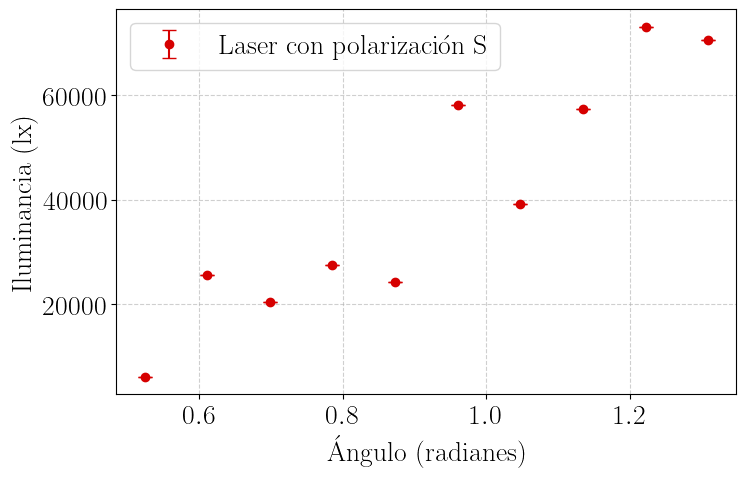

In [4]:
# Graficar el primer directorio
plt.figure(figsize=(8, 5))
subset_primer_directorio = results_df[results_df["Directorio"] == primer_directorio]
plt.errorbar(subset_primer_directorio["Ángulo (radianes)"], 
             subset_primer_directorio["Iluminancia promedio (lx)"], 
             yerr=subset_primer_directorio["Incertidumbre (lx)"], 
             fmt='o', capsize=5, label="Laser con polarización S")

# Configuración de la gráfica para el primer directorio
plt.xlabel("Ángulo (radianes)")
plt.ylabel("Iluminancia (lx)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

### Reflectancia (no normalizada - radianes)

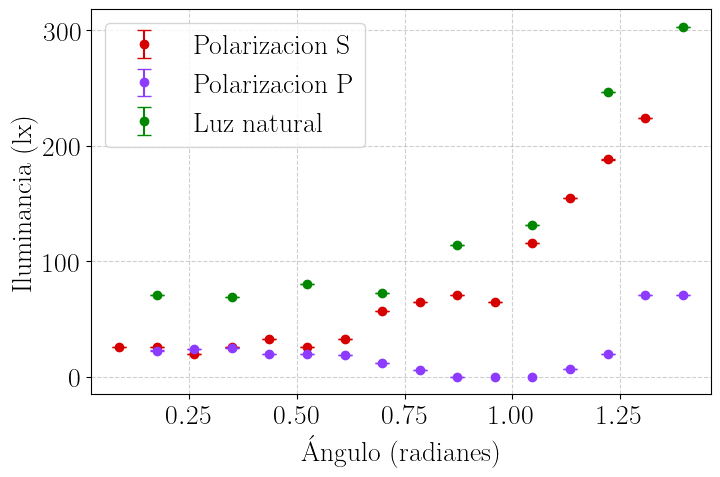

In [5]:
# Graficar los otros directorios
plt.figure(figsize=(8, 5))
labels = ["Polarizacion S", "Polarizacion P", "Luz natural"]
for i, directorio in enumerate(otros_directorios):
    subset = results_df[results_df["Directorio"] == directorio]
    plt.errorbar(subset["Ángulo (radianes)"], 
                 subset["Iluminancia promedio (lx)"], 
                 yerr=subset["Incertidumbre (lx)"], 
                 fmt='o', capsize=5, label=labels[i])

# Configuración de la gráfica para los otros directorios
plt.xlabel("Ángulo (radianes)")
plt.ylabel("Iluminancia (lx)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


### Reflectancia (normalizada)

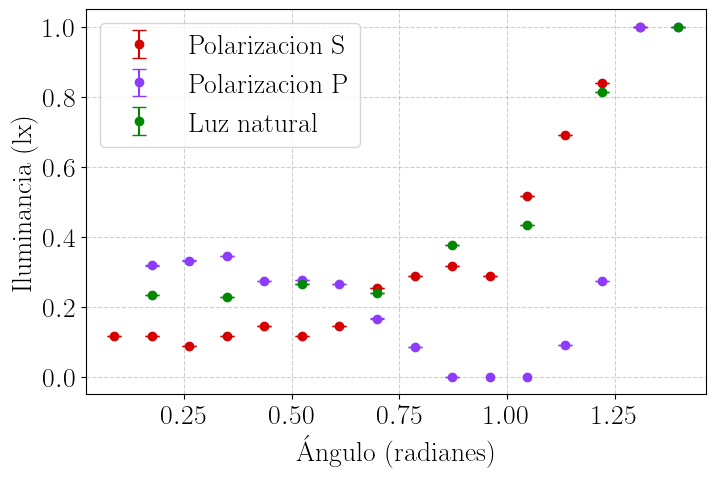

In [6]:
# Graficar los otros directorios normalizado
plt.figure(figsize=(8, 5))
labels = ["Polarizacion S", "Polarizacion P", "Luz natural"]
for i, directorio in enumerate(otros_directorios):
    subset = results_df[results_df["Directorio"] == directorio]
    plt.errorbar(subset["Ángulo (radianes)"], 
                 subset["Iluminancia promedio (lx)"]/max(subset["Iluminancia promedio (lx)"]), 
                 yerr=subset["Incertidumbre (lx)"]/max(subset["Iluminancia promedio (lx)"]), 
                 fmt='o', capsize=5, label=labels[i])

# Configuración de la gráfica para los otros directorios
plt.xlabel("Ángulo (radianes)")
plt.ylabel("Iluminancia (lx)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [7]:
results_df_original = results_df.copy()

## Ajuste para datos de Luz linterna con polarizacion P

# Identificar datos que son cero para el tercer directorio
tercer_directorio = results_df["Directorio"].unique()[2]
subset_tercer_directorio = results_df[results_df["Directorio"] == tercer_directorio]
subset_tercer_directorio_original = results_df_original[results_df_original["Directorio"] == tercer_directorio]  


# Filtrar filas donde la iluminancia promedio es cero
datos_cero = subset_tercer_directorio[subset_tercer_directorio["Iluminancia promedio (lx)"] == 0]

# Remover filas con iluminancia promedio cero del DataFrame original
results_df = results_df[results_df["Iluminancia promedio (lx)"] != 0]

print("Datos con iluminancia cero para el tercer directorio:")
print(datos_cero)
print(results_df)

# Remover filas con ángulo de 80 grados para el tercer directorio
results_df = results_df[~((results_df["Directorio"] == tercer_directorio) & (results_df["Ángulo (grados)"] == 80))]
subset_tercer_directorio_original = subset_tercer_directorio_original[~(subset_tercer_directorio_original["Ángulo (grados)"] == 80)]

print("Datos después de remover ángulo de 80 grados para el tercer directorio:")
print(results_df)

Datos con iluminancia cero para el tercer directorio:
                                   Directorio  Ángulo (grados)  \
33  data/LuzLinternaP/organizados_por_grados/             50.0   
34  data/LuzLinternaP/organizados_por_grados/             55.0   
35  data/LuzLinternaP/organizados_por_grados/             60.0   

    Iluminancia promedio (lx)  Incertidumbre (lx)  Ángulo (radianes)  
33                        0.0                 0.0           0.872665  
34                        0.0                 NaN           0.959931  
35                        0.0                 NaN           1.047198  
                                           Directorio  Ángulo (grados)  \
0              data/LuzLaserS/organizados_por_grados/             30.0   
1              data/LuzLaserS/organizados_por_grados/             35.0   
2              data/LuzLaserS/organizados_por_grados/             40.0   
3              data/LuzLaserS/organizados_por_grados/             45.0   
4              data/LuzLase

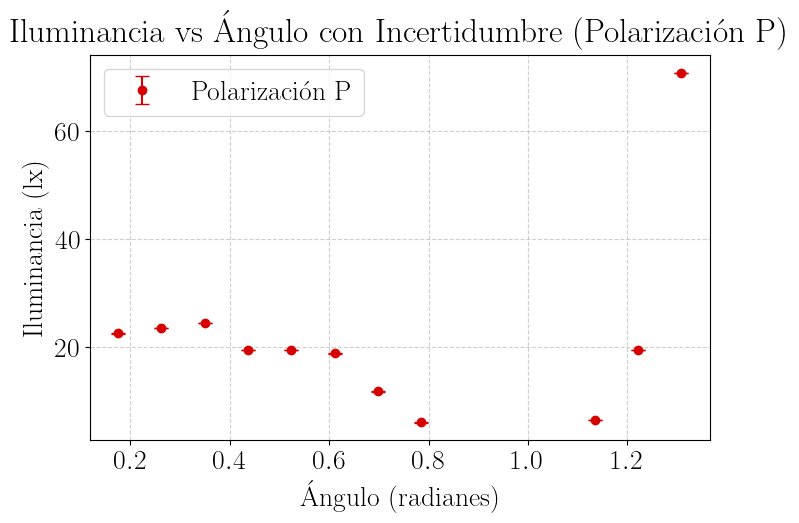

In [8]:
# Graficar solo los datos de polarización P
plt.figure(figsize=(8, 5))
subset_polarizacion_p = results_df[results_df["Directorio"] == tercer_directorio]

plt.errorbar(subset_polarizacion_p["Ángulo (radianes)"], 
             subset_polarizacion_p["Iluminancia promedio (lx)"], 
             yerr=subset_polarizacion_p["Incertidumbre (lx)"], 
             fmt='o', capsize=5, label="Polarización P")

# Configuración de la gráfica para polarización P
plt.xlabel("Ángulo (radianes)")
plt.ylabel("Iluminancia (lx)")
plt.title("Iluminancia vs Ángulo con Incertidumbre (Polarización P)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Mostrar la gráfica
plt.show()

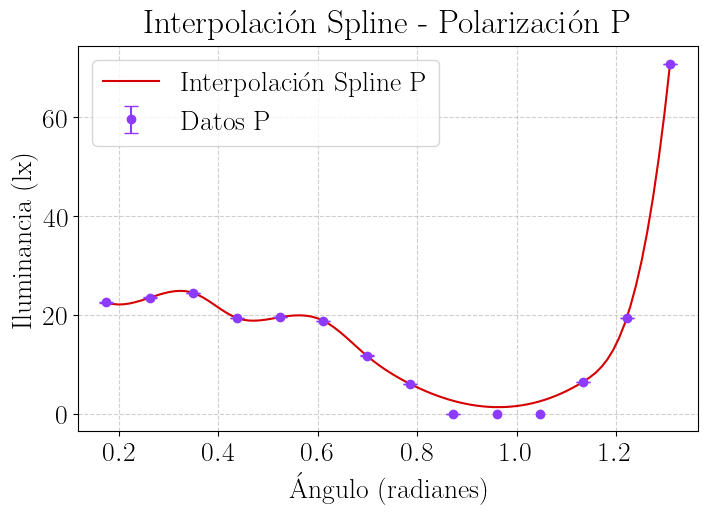

In [9]:
# Interpolacion spline para polarizacion P
subset_polarizacion_p = results_df[results_df["Directorio"] == tercer_directorio]
subset_polarizacion_p = subset_polarizacion_p.sort_values("Ángulo (radianes)").drop_duplicates()
x_p = subset_polarizacion_p["Ángulo (radianes)"].values
y_p = subset_polarizacion_p["Iluminancia promedio (lx)"].values
x_spline = np.linspace(x_p.min(), x_p.max(), 100)
spline_func = make_interp_spline(x_p, y_p, k=3)
y_spline = spline_func(x_spline)

plt.figure(figsize=(8,5))
plt.plot(x_spline, y_spline, '-', label="Interpolación Spline P")
plt.errorbar(subset_tercer_directorio_original["Ángulo (radianes)"], subset_tercer_directorio_original["Iluminancia promedio (lx)"],
             yerr=subset_tercer_directorio_original["Incertidumbre (lx)"],
             fmt='o', capsize=5, label="Datos P")
plt.xlabel("Ángulo (radianes)")
plt.ylabel("Iluminancia (lx)")
plt.title("Interpolación Spline - Polarización P")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

### Polarizaciones

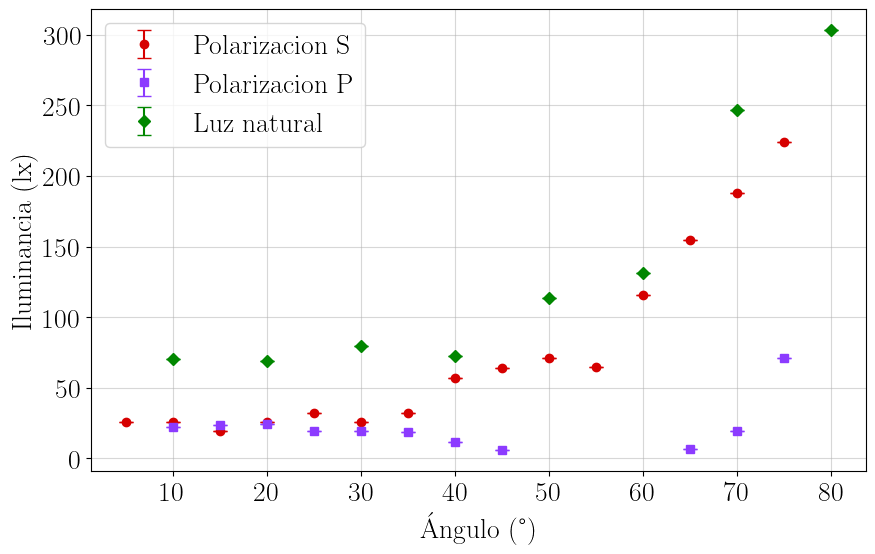

In [10]:
# Graficar los otros directorios
plt.figure(figsize=(10, 6))
labels = ["Polarizacion S", "Polarizacion P", "Luz natural"]
markers = ['o', 's', 'D']  # Different markers for each dataset

for i, directorio in enumerate(otros_directorios):
    subset = results_df[results_df["Directorio"] == directorio]
    plt.errorbar(np.degrees(subset["Ángulo (radianes)"]), 
                 subset["Iluminancia promedio (lx)"], 
                 yerr=subset["Incertidumbre (lx)"], 
                 fmt=markers[i], capsize=5, label=labels[i])

# Configuración de la gráfica para los otros directorios
plt.xlabel("Ángulo (°)")
plt.ylabel("Iluminancia (lx)")
plt.legend()
plt.show()

In [11]:
results_df_original = results_df.copy()

## Ajuste para datos de Luz linterna con polarizacion P

# Identificar datos que son cero para el tercer directorio
tercer_directorio = results_df["Directorio"].unique()[2]
subset_tercer_directorio = results_df[results_df["Directorio"] == tercer_directorio]
subset_tercer_directorio_original = results_df_original[results_df_original["Directorio"] == tercer_directorio]  


# Filtrar filas donde la iluminancia promedio es cero
datos_cero = subset_tercer_directorio[subset_tercer_directorio["Iluminancia promedio (lx)"] == 0]

# Remover filas con iluminancia promedio cero del DataFrame original
results_df = results_df[results_df["Iluminancia promedio (lx)"] != 0]

print("Datos con iluminancia cero para el tercer directorio:")
print(datos_cero)
print(results_df)

# Remover filas con ángulo de 80 grados para el tercer directorio
results_df = results_df[~((results_df["Directorio"] == tercer_directorio) & (results_df["Ángulo (grados)"] == 80))]
subset_tercer_directorio_original = subset_tercer_directorio_original[~(subset_tercer_directorio_original["Ángulo (grados)"] == 80)]

print("Datos después de remover ángulo de 80 grados para el tercer directorio:")
print(results_df)



Datos con iluminancia cero para el tercer directorio:
Empty DataFrame
Columns: [Directorio, Ángulo (grados), Iluminancia promedio (lx), Incertidumbre (lx), Ángulo (radianes)]
Index: []
                                           Directorio  Ángulo (grados)  \
0              data/LuzLaserS/organizados_por_grados/             30.0   
1              data/LuzLaserS/organizados_por_grados/             35.0   
2              data/LuzLaserS/organizados_por_grados/             40.0   
3              data/LuzLaserS/organizados_por_grados/             45.0   
4              data/LuzLaserS/organizados_por_grados/             50.0   
5              data/LuzLaserS/organizados_por_grados/             55.0   
6              data/LuzLaserS/organizados_por_grados/             60.0   
7              data/LuzLaserS/organizados_por_grados/             65.0   
8              data/LuzLaserS/organizados_por_grados/             70.0   
9              data/LuzLaserS/organizados_por_grados/             75.0   
1

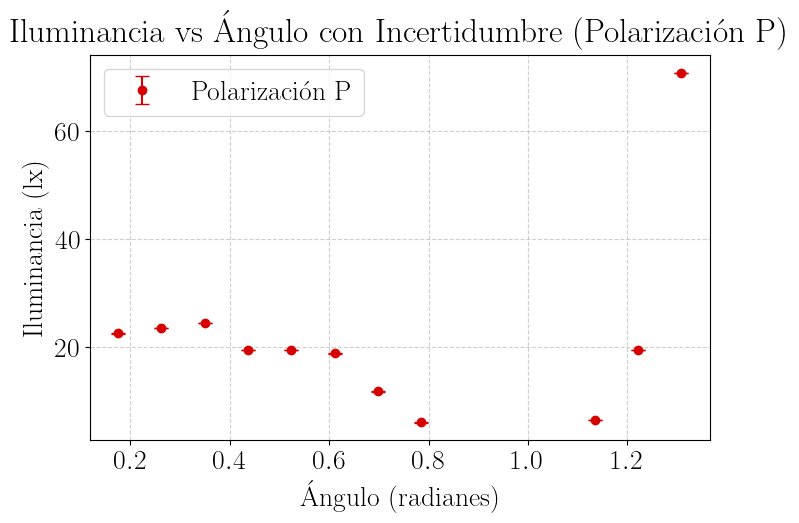

In [12]:
# Graficar solo los datos de polarización P
plt.figure(figsize=(8, 5))
subset_polarizacion_p = results_df[results_df["Directorio"] == tercer_directorio]

plt.errorbar(subset_polarizacion_p["Ángulo (radianes)"], 
             subset_polarizacion_p["Iluminancia promedio (lx)"], 
             yerr=subset_polarizacion_p["Incertidumbre (lx)"], 
             fmt='o', capsize=5, label="Polarización P")

# Configuración de la gráfica para polarización P
plt.xlabel("Ángulo (radianes)")
plt.ylabel("Iluminancia (lx)")
plt.title("Iluminancia vs Ángulo con Incertidumbre (Polarización P)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Mostrar la gráfica
plt.show()

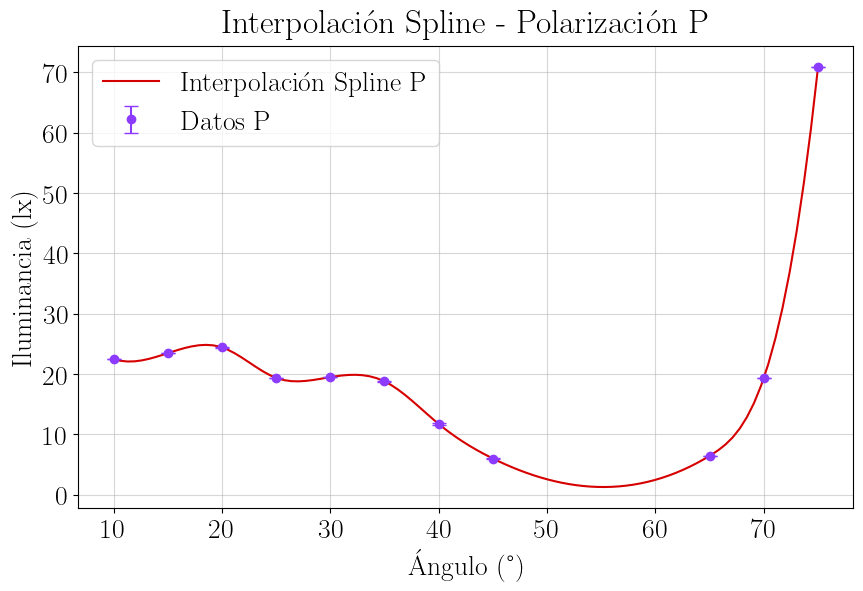

In [13]:
# Interpolacion spline para polarizacion P
subset_polarizacion_p = results_df[results_df["Directorio"] == tercer_directorio]
subset_polarizacion_p = subset_polarizacion_p.sort_values("Ángulo (radianes)").drop_duplicates()
x_p = subset_polarizacion_p["Ángulo (radianes)"].values
y_p = subset_polarizacion_p["Iluminancia promedio (lx)"].values
x_spline = np.linspace(x_p.min(), x_p.max(), 100)
spline_func = make_interp_spline(x_p, y_p, k=3)
y_spline = spline_func(x_spline)

plt.figure(figsize=(10,6))
plt.plot(np.degrees(x_spline), y_spline, '-', label="Interpolación Spline P")
plt.errorbar(np.degrees(subset_tercer_directorio_original["Ángulo (radianes)"]), 
             subset_tercer_directorio_original["Iluminancia promedio (lx)"],
             yerr=subset_tercer_directorio_original["Incertidumbre (lx)"],
             fmt='o', capsize=5, label="Datos P")
plt.xlabel("Ángulo (°)")
plt.ylabel("Iluminancia (lx)")
plt.title("Interpolación Spline - Polarización P")
plt.legend()
plt.show()

[3.57088818]


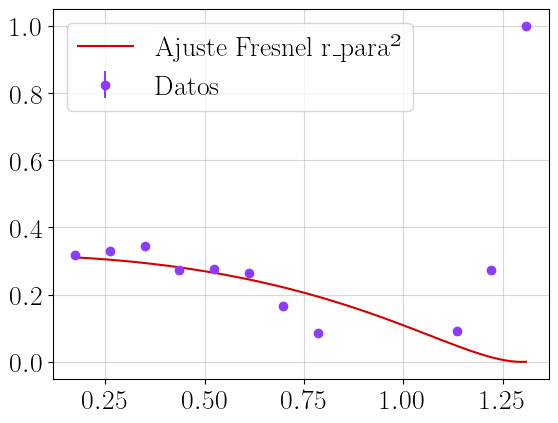

In [14]:
# Ajuste para polarizacion P con coeficiente de reflexion paralalela al cuadrado

# Definir el modelo teórico de Fresnel para r_perp^2 con n_i = 1
def fresnel_r_para_squared(theta_i, n_t):
    theta_t = np.arcsin((1 / n_t) * np.sin(theta_i))  # Ley de Snell
    r_perp_squared = ((np.cos(theta_t) - n_t * np.cos(theta_i)) / 
                      (np.cos(theta_t) + n_t * np.cos(theta_i))) ** 2
    return r_perp_squared


# Ajustar la curva a los datos experimentales
# def model(theta_i, n_t):
#     return fresnel_r_para_squared(theta_i, n_t)

# Ajuste de los datos
p0 = [1.5, 1.0]
params, cov = curve_fit(fresnel_r_para_squared, x_p, y_p/np.max(y_p),p0=[1.4])
n_t_fit = params

# Curva ajustada
theta_fit = np.linspace(x_p.min(), x_p.max(), 100)
fit_values = fresnel_r_para_squared(theta_fit, n_t_fit)

print(n_t_fit)
# Graficar ajuste
plt.plot(theta_fit, fit_values, label="Ajuste Fresnel r_para²")
plt.errorbar(x_p, y_p/np.max(y_p), yerr=subset_polarizacion_p["Incertidumbre (lx)"]/np.max(y_p), fmt='o', label="Datos")
plt.legend()
plt.show()

